In [3]:
import numpy as np
from numba import *
import matplotlib.pyplot as plt

Model with a null fundamental price

Parameters

In [51]:
kappa = 0.08
beta = 0.1
gamma = 50
alpha = 0.1

In [ ]:
T = 1000

eps = np.random.normal(0, 1, T)
eta = np.random.normal(0, 1, T)

p = np.zeros(T)
m = np.zeros(T)
v = np.zeros(T)

v[0] = 30
v[1] = v[0] + eta[1]
p[0] = v[0]
p[1] = p[0]
m[0] = 0
m[1] = 0

for t in range(1, T-1):
    p[t+1] = (
        p[t]
        + kappa * (v[t] - p[t])
        + beta * np.tanh(gamma * m[t])
        + eps[t+1]
    )

    m[t+1] = (1 - alpha) * m[t] + alpha * (p[t] - p[t-1])

    v[t+1] = v[t] + eta[t+1]

    

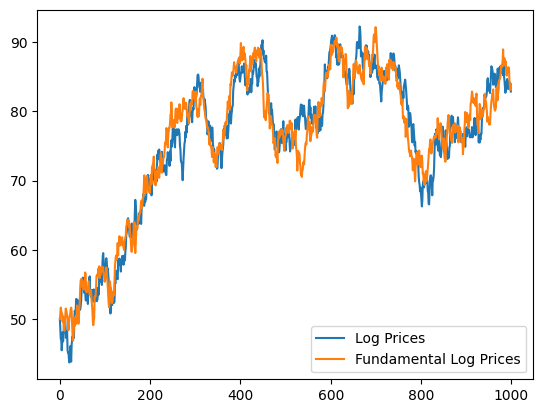

In [61]:
plt.plot(log_prices)
plt.plot(fundamental_log_prices)
plt.legend(["Log Prices", "Fundamental Log Prices"])
plt.show()

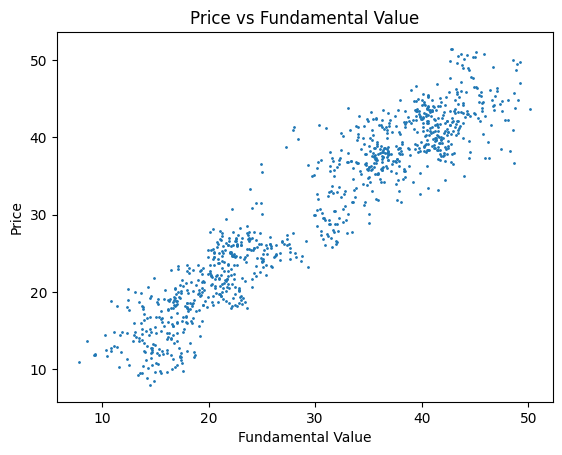

In [62]:
plt.scatter(v, p, s=1)
plt.xlabel("Fundamental Value")
plt.ylabel("Price")
plt.title("Price vs Fundamental Value")
plt.show()

As the fundamental price goes up so does the market price